#Zomato Data Analysis

### Step 1: Importing library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Creating Data Frame

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Data_Analysis/Zomato data.csv")

In [6]:
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

###Step 3: Data Cleaning

In [8]:
# Converting data type of column - rate

def handleRate(value):
  value = str(value).split("/")
  value = value[0]
  return float(value)

df["rate"] = df["rate"].apply(handleRate)
print(df.head)


<bound method NDFrame.head of                       name online_order book_table  rate  votes  \
0                    Jalsa          Yes        Yes   4.1    775   
1           Spice Elephant          Yes         No   4.1    787   
2          San Churro Cafe          Yes         No   3.8    918   
3    Addhuri Udupi Bhojana           No         No   3.7     88   
4            Grand Village           No         No   3.8    166   
..                     ...          ...        ...   ...    ...   
143       Melting Melodies           No         No   3.3      0   
144        New Indraprasta           No         No   3.3      0   
145           Anna Kuteera          Yes         No   4.0    771   
146                 Darbar           No         No   3.0     98   
147          Vijayalakshmi          Yes         No   3.9     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2           

In [9]:
#checking null value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


### Step 4: Data Analysis

1. Finding types of restraunt

In [10]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of restrant')

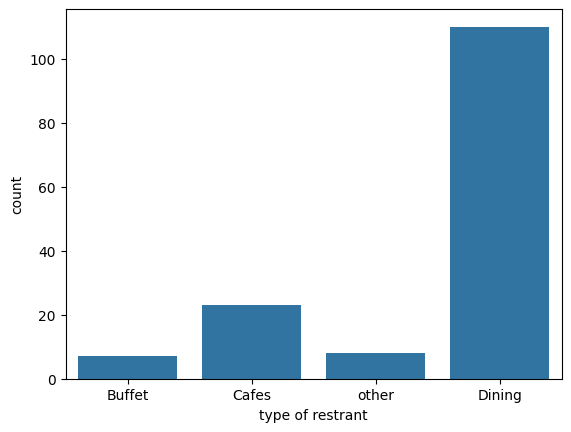

In [12]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('type of restrant')

Conclusion - Majority of resturant falls under dinning category

2. How many votes each type of resturant recieved?

Text(0, 0.5, 'Votes')

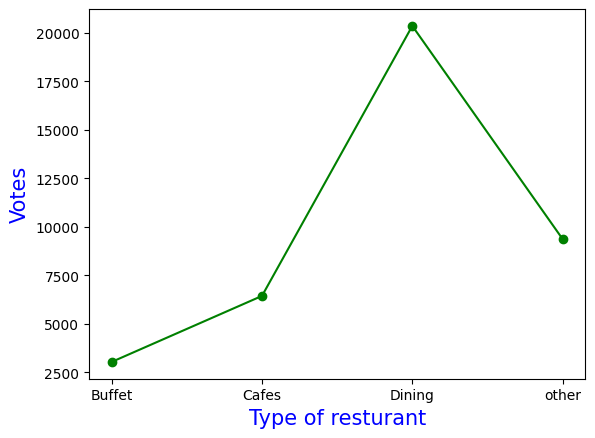

In [17]:
group_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': group_data})
plt.plot(result, c="green", marker ="o")
plt.xlabel("Type of resturant", c="blue", size=15)
plt.ylabel("Votes", c="blue", size=15)

Conclusion - Dinning resturant has recieved maximum votes

3. Type of rating majority of resturant recieved

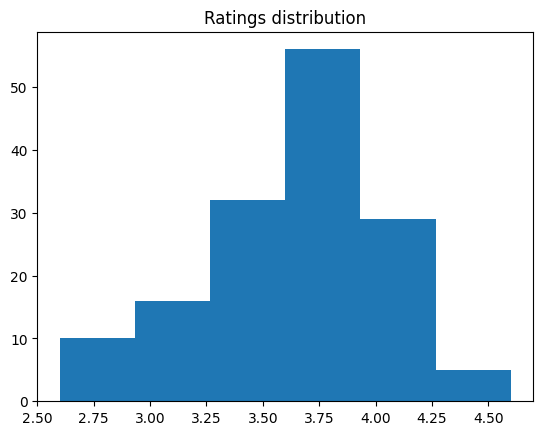

In [21]:
plt.hist(df['rate'],bins =6)
plt.title("Ratings distribution")
plt.show()

Conclusion - Majority resturant recieved rating from 3.5 to 4

4. Average order spending by couple

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

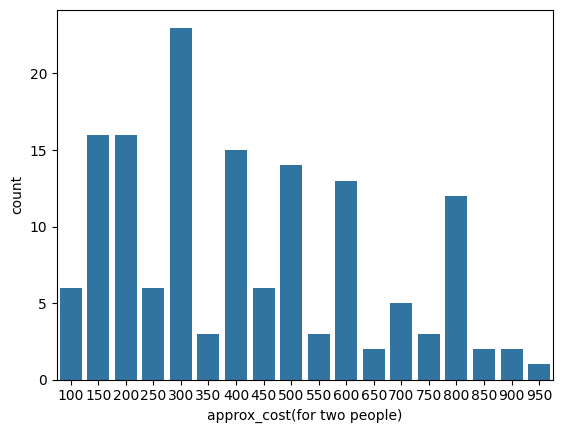

In [25]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data)

Conclusion - Majority of couple prefer resturant with an approximate  cost of 300 ruppes

5. Which mode has recieved maximum ratings(online or offline)?

<Axes: xlabel='online_order', ylabel='rate'>

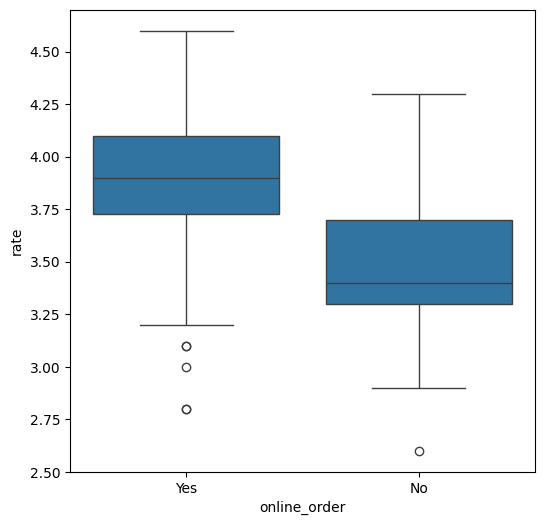

In [27]:
plt.figure(figsize =(6,6))
sns.boxplot(x = 'online_order', y = "rate", data = df)

Conclusion - Offline order recieved lower rating than online order

6. Which type of resturant recieved more offline order?


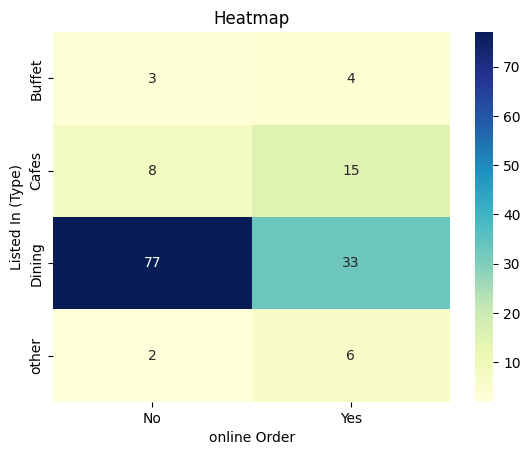

In [30]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns ='online_order', aggfunc = 'size', fill_value = 0)
sns.heatmap(pivot_table, annot= True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("online Order")
plt.ylabel("Listed In (Type)")
plt.show()

Conclusion - Dining resturant primarily recieve order in offline mode while other type of rsturant recieve more online order.